In [126]:
import pandas as pd
import sys

from sqlalchemy import create_engine
from datetime import datetime

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, RocCurveDisplay, ConfusionMatrixDisplay

import matplotlib.pyplot as plt

import sys
sys.path.insert(0, '../backend')

from dotenv import load_dotenv
load_dotenv('../.env')

from app.config import DATABASE_URL

In [121]:
engine = create_engine(DATABASE_URL)

game_df = pd.read_sql_table("game_overview_data", engine)
team_df = pd.read_sql_table("team_data", engine)

## Building Team Level Features and Stats

In [ ]:
def get_team_rolling_stats(team_id: int, as_of_date: datetime | None = None) -> pd.DataFrame:
    """Compute rolling average stats for a given team up to a specified date."""
    as_of_date = as_of_date or datetime.today()

    team_games = game_df[(game_df['team_id'] == team_id) & (game_df['game_date'] < as_of_date)].copy()

    rolling_cols = ['pts', 'dreb', 'fg_pct', 'fg3_pct', 'ft_pct', 'ast', 'reb', 'stl', 'blk', 'tov', 'pf', 'wl', 'plus_minus']

    team_games = team_games.sort_values(['team_id', 'game_date'])
    team_games['wl'] = team_games['wl'].astype(int)

    windows = [3, 5, 7, 10]

    for window in windows:
        for col in rolling_cols:
            team_games[f'{window}_game_rolling_{col}'] = (
                team_games.groupby(['team_id', 'season_id'])[col]
                .transform(lambda x: x.rolling(window, min_periods=1).mean()))

    team_games['games_played'] = team_games.groupby(['team_id', 'season_id']).cumcount() + 1

    return team_games

g = get_team_rolling_stats(1610612743)

teams_rolling_stats = pd.concat([get_team_rolling_stats(team_id) for team_id in team_df['team_id'].unique()], ignore_index=True)
teams_rolling_stats.head()

,season_id,team_id,team_abbreviation,team_name,game_id,game_date,matchup,wl,min,pts,...,10_game_rolling_ft_pct,10_game_rolling_ast,10_game_rolling_reb,10_game_rolling_stl,10_game_rolling_blk,10_game_rolling_tov,10_game_rolling_pf,10_game_rolling_wl,10_game_rolling_plus_minus,games_played
0,22024,1610612737,ATL,Atlanta Hawks,22400064,2024-10-23,ATL vs. BKN,1,241,120,...,0.717000,25.000000,45.000000,12.0,9.000000,16.0,20.000000,1.000000,4.00,1
1,22024,1610612737,ATL,Atlanta Hawks,22400079,2024-10-25,ATL vs. CHA,1,240,125,...,0.792500,25.000000,42.000000,11.5,9.000000,14.5,24.000000,1.000000,4.50,2
2,22024,1610612737,ATL,Atlanta Hawks,22400100,2024-10-27,ATL @ OKC,0,240,104,...,0.781333,24.666667,44.333333,10.0,7.333333,16.0,23.666667,0.666667,-5.00,3
3,22024,1610612737,ATL,Atlanta Hawks,22400103,2024-10-28,ATL vs. WAS,0,240,119,...,0.766500,26.500000,43.000000,10.5,7.250000,16.0,23.250000,0.500000,-4.25,4
4,22024,1610612737,ATL,Atlanta Hawks,22400121,2024-10-30,ATL @ WAS,0,240,120,...,0.784600,26.800000,42.600000,10.4,6.400000,15.8,22.400000,0.400000,-6.00,5


In [123]:
def build_feature_set(teams_rolling_stats, game_df, team_df):
    """Build a feature set for modeling based on rolling stats and game data."""
    training_rows = []

    team_ids = team_df[['team_id', 'abbreviation']].drop_duplicates()

    for game_id in game_df['game_id'].unique():
        game = game_df[
            (game_df['game_id'] == game_id) & 
            (game_df['matchup'].str.contains('vs'))
        ].copy()
        if len(game) == 0:
            continue

        game_date = game['game_date'].values[0]

        home_team_abbr = game['matchup'].values[0].split(' ')[0]
        away_team_abbr = game['matchup'].values[0].split(' ')[2]
        home_team_id = team_ids[team_ids['abbreviation'] == home_team_abbr]['team_id'].values[0]
        away_team_id = team_ids[team_ids['abbreviation'] == away_team_abbr]['team_id'].values[0]
        home_wl = game['wl'].values[0]

        # Actual points scored in this game (targets for regression)
        home_pts_actual = game['pts'].values[0]
        away_game = game_df[
            (game_df['game_id'] == game_id) &
            (game_df['matchup'].str.contains(' @ '))
        ].copy()
        away_pts_actual = away_game['pts'].values[0] if len(away_game) > 0 else None

        home_prior = teams_rolling_stats[
            (teams_rolling_stats['team_id'] == home_team_id) & 
            (teams_rolling_stats['game_date'] < game_date)
        ].sort_values('game_date')
        away_prior = teams_rolling_stats[
            (teams_rolling_stats['team_id'] == away_team_id) & 
            (teams_rolling_stats['game_date'] < game_date)
        ].sort_values('game_date')

        if len(home_prior) == 0 or len(away_prior) == 0:
            continue

        home_stats = home_prior.iloc[-1].drop(labels=['wl', 'game_id', 'game_date'])
        away_stats = away_prior.iloc[-1].drop(labels=['wl', 'game_id', 'game_date'])

        home_last_game_date = home_prior.iloc[-1]['game_date']
        away_last_game_date = away_prior.iloc[-1]['game_date']

        home_rest = (pd.Timestamp(game_date) - pd.Timestamp(home_last_game_date)).days
        away_rest = (pd.Timestamp(game_date) - pd.Timestamp(away_last_game_date)).days

        row = {
            'game_id': game_id,
            'game_date': game_date,
            'home_wl': home_wl,
            'home_pts_actual': home_pts_actual,
            'away_pts_actual': away_pts_actual,
            'home_rest_days': home_rest,
            'away_rest_days': away_rest,
            **{f'home_{k}': v for k, v in home_stats.items()},
            **{f'away_{k}': v for k, v in away_stats.items()},
        }

        training_rows.append(row)

    return pd.DataFrame(training_rows)


training_data = build_feature_set(teams_rolling_stats, game_df, team_df)
training_data.head()


,game_id,game_date,home_wl,home_pts_actual,away_pts_actual,home_rest_days,away_rest_days,home_season_id,home_team_id,home_team_abbreviation,...,away_10_game_rolling_ft_pct,away_10_game_rolling_ast,away_10_game_rolling_reb,away_10_game_rolling_stl,away_10_game_rolling_blk,away_10_game_rolling_tov,away_10_game_rolling_pf,away_10_game_rolling_wl,away_10_game_rolling_plus_minus,away_games_played
0,22501155,2026-04-07,False,87,123,2,2,22025,1610612747,LAL,...,0.8147,26.5,47.1,9.1,5.5,12.6,18.5,0.9,17.6,78
1,22501156,2026-04-07,True,116,103,2,2,22025,1610612746,LAC,...,0.7477,26.1,42.8,8.9,4.3,13.0,19.6,0.2,-10.5,78
2,22501157,2026-04-07,False,103,117,2,2,22025,1610612756,PHX,...,0.7845,30.7,47.0,7.3,6.2,12.7,15.7,0.8,11.3,78
3,22501150,2026-04-07,True,96,90,2,2,22025,1610612751,BKN,...,0.7375,23.9,39.1,8.1,3.6,17.7,20.0,0.3,-13.7,78
4,22501152,2026-04-07,False,104,124,2,2,22025,1610612754,IND,...,0.7437,25.7,45.4,9.2,6.6,14.2,20.0,0.5,3.3,78


In [ ]:
def build_matchup_features(rolling_stats: pd.DataFrame, home_id: int, away_id: int, matchup_date: datetime | None = None) -> pd.DataFrame:
    """Build a feature vector for a specific matchup based on the most recent rolling stats for each team."""
    matchup_date = matchup_date or datetime.today()

    home_prior = rolling_stats[(rolling_stats['team_id'] == home_id) & (rolling_stats['game_date'] < matchup_date)].sort_values('game_date')
    away_prior = rolling_stats[(rolling_stats['team_id'] == away_id) & (rolling_stats['game_date'] < matchup_date)].sort_values('game_date')

    home_stats = home_prior.iloc[-1].drop(labels=['wl', 'game_id', 'game_date', 'matchup', 'team_id', 'team_abbreviation', 'team_name', 'pull_date'])
    away_stats = away_prior.iloc[-1].drop(labels=['wl', 'game_id', 'game_date', 'matchup', 'team_id', 'team_abbreviation', 'team_name', 'pull_date'])

    home_last_game_date = home_prior.iloc[-1]['game_date']
    away_last_game_date = away_prior.iloc[-1]['game_date']

    home_rest = (pd.Timestamp(matchup_date) - pd.Timestamp(home_last_game_date)).days
    away_rest = (pd.Timestamp(matchup_date) - pd.Timestamp(away_last_game_date)).days

    row = {
        'home_rest_days': home_rest, 
        'away_rest_days': away_rest,
        **{f'home_{k}': v for k, v in home_stats.items()},
        **{f'away_{k}': v for k, v in away_stats.items()},
    }

    return pd.DataFrame(row, index=[0])

build_matchup_features(teams_rolling_stats, 1610612743, 1610612747, datetime(2026, 4, 3)).head()

,home_rest_days,away_rest_days,home_season_id,home_min,home_pts,home_fgm,home_fga,home_fg_pct,home_fg3m,home_fg3a,...,away_10_game_rolling_ft_pct,away_10_game_rolling_ast,away_10_game_rolling_reb,away_10_game_rolling_stl,away_10_game_rolling_blk,away_10_game_rolling_tov,away_10_game_rolling_pf,away_10_game_rolling_wl,away_10_game_rolling_plus_minus,away_games_played
0,2,1,22025,240,130,44,91,0.484,16,39,...,0.7694,23.9,40.5,9.3,5.4,12.8,17.8,0.8,3.6,77


## Predicting Game Matchup Winner (Classification)

In [127]:
def fit_evaluate_model_matchup_prediction(feature_set: pd.DataFrame, model: object, split_date: datetime | None = None, verbose: bool = True):
    split_date = split_date or datetime.today()

    drop_cols = [col for col in feature_set.columns if 
             "rolling" not in col and 
             "home_games_played" not in col and 
             "away_games_played" not in col and 
             "rest" not in col]

    X = feature_set.drop(columns = drop_cols)
    y = feature_set["home_wl"].astype(int)

    train_mask = feature_set['game_date'] < split_date
    X_train, y_train = X[train_mask], y[train_mask]
    X_test, y_test = X[~train_mask], y[~train_mask]

    print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    if verbose: 
        print(f"Model accuracy: {accuracy:.2f}")
        print("Confusion Matrix:")
        ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
        plt.show()
        print("ROC Curve:")
        RocCurveDisplay.from_predictions(y_test, y_pred)
        plt.show()
        print("Classification Report:")
        print(classification_report(y_test, y_pred))
    
    return model, X, y

Evaluating Random Forest...
(1933, 108) (1933,) (455, 108) (455,)
Model accuracy: 0.67
Confusion Matrix:


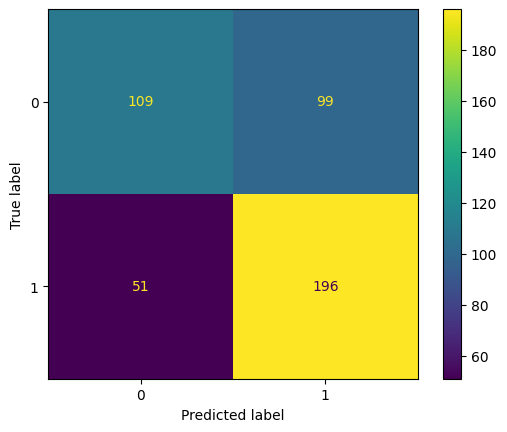

ROC Curve:


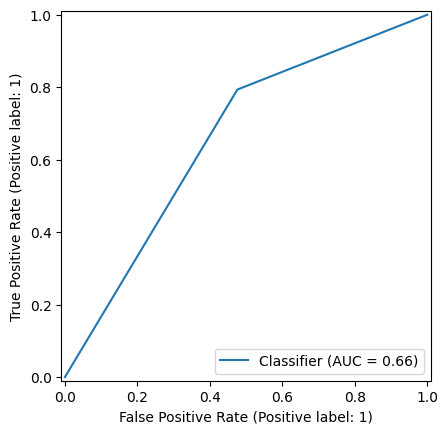

Classification Report:
              precision    recall  f1-score   support

           0       0.68      0.52      0.59       208
           1       0.66      0.79      0.72       247

    accuracy                           0.67       455
   macro avg       0.67      0.66      0.66       455
weighted avg       0.67      0.67      0.66       455

Evaluating Logistic Regression...
(1933, 108) (1933,) (455, 108) (455,)
Model accuracy: 0.71
Confusion Matrix:


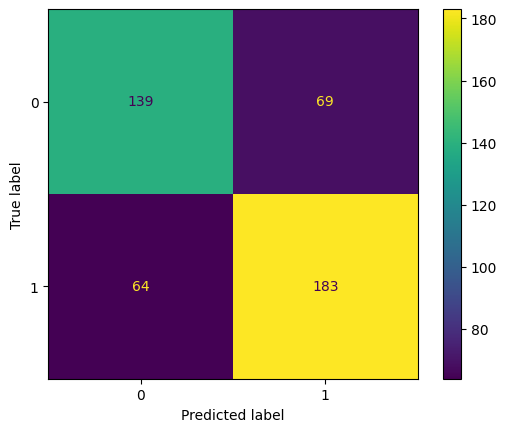

ROC Curve:


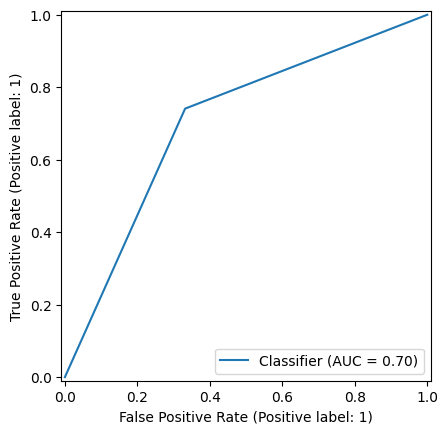

Classification Report:
              precision    recall  f1-score   support

           0       0.68      0.67      0.68       208
           1       0.73      0.74      0.73       247

    accuracy                           0.71       455
   macro avg       0.71      0.70      0.70       455
weighted avg       0.71      0.71      0.71       455

Evaluating Gradient Boosting...
(1933, 108) (1933,) (455, 108) (455,)
Model accuracy: 0.67
Confusion Matrix:


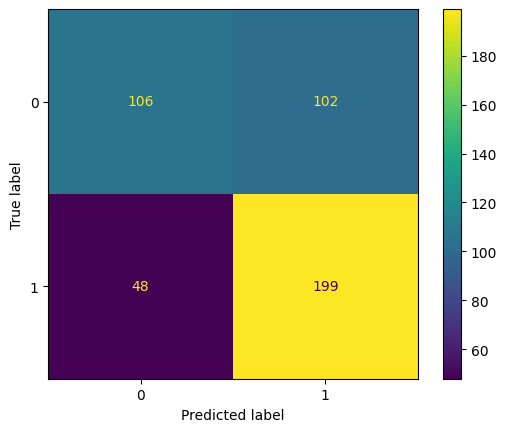

ROC Curve:


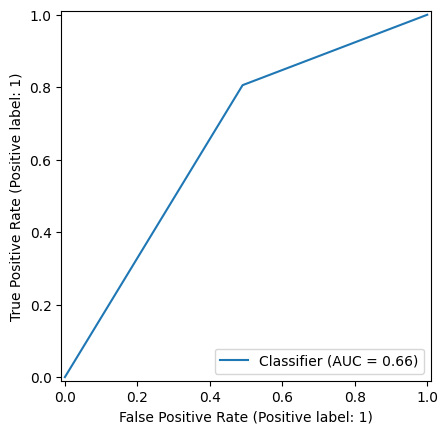

Classification Report:
              precision    recall  f1-score   support

           0       0.69      0.51      0.59       208
           1       0.66      0.81      0.73       247

    accuracy                           0.67       455
   macro avg       0.67      0.66      0.66       455
weighted avg       0.67      0.67      0.66       455



In [128]:
models = {
    "Random Forest": RandomForestClassifier(n_estimators=1000, random_state=42), 
    "Logistic Regression": LogisticRegression(max_iter=100000, random_state=42), 
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=42)
}

for model in models:
    print(f"Evaluating {model}...")
    _, X, y = fit_evaluate_model_matchup_prediction(training_data, models[model], split_date=datetime(2026, 2, 1))

lr_feature_importance = pd.Series(models['Logistic Regression'].coef_[0], index=X.columns).sort_values(ascending=False)
rf_feature_importance = pd.Series(models['Random Forest'].feature_importances_, index=X.columns).sort_values(ascending=False)
gb_feature_importance = pd.Series(models['Gradient Boosting'].feature_importances_, index=X.columns).sort_values(ascending=False)

In [129]:
def predict_game_matchup(home_team_abbr: str, 
                 away_team_abbr: str, 
                 game_date: datetime, 
                 teams_rolling_stats: pd.DataFrame, 
                 feature_set: pd.DataFrame,  
                 team_df: pd.DataFrame, 
                 model: object):
    
    home_team_id = team_df[team_df['abbreviation'] == home_team_abbr]['team_id'].values[0]
    away_team_id = team_df[team_df['abbreviation'] == away_team_abbr]['team_id'].values[0]

    feature_set = feature_set[feature_set['game_date'] < game_date]

    matchup_features = build_matchup_features(teams_rolling_stats, home_team_id, away_team_id, game_date)

    model, X, y = fit_evaluate_model_matchup_prediction(feature_set, model, game_date, verbose = False)

    matchup_features = matchup_features[X.columns]

    return model.predict_proba(matchup_features)[0][1]

## Predicting Team Points Scored in Matchup (Regression)

In [131]:
def fit_evaluate_model_score_prediction(feature_set: pd.DataFrame, home: bool, model: object, split_date=None, verbose: bool = True):
    split_date = pd.Timestamp(split_date) if split_date else pd.Timestamp.today()

    feature_set = feature_set.copy()
    feature_set['game_date'] = pd.to_datetime(feature_set['game_date'])

    drop_cols = [col for col in feature_set.columns if
             'rolling' not in col and
             'home_games_played' not in col and
             'away_games_played' not in col and
             'rest' not in col]

    y_col = 'home_pts_actual' if home else 'away_pts_actual'
    y = feature_set[y_col]
    X = feature_set.drop(columns=drop_cols)

    # Ensure no target columns leak into X
    for col in ['home_wl', 'home_pts_actual', 'away_pts_actual']:
        if col in X.columns:
            X = X.drop(columns=[col])

    if verbose:
        train_mask = feature_set['game_date'] < split_date
        X_train, y_train = X[train_mask], y[train_mask]
        X_test, y_test = X[~train_mask], y[~train_mask]
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        rmse = ((y_test - y_pred) ** 2).mean() ** 0.5
        print(f'Model RMSE: {rmse:.2f} pts')
        return model, X_test, y_test, y_pred
    else:
        model.fit(X, y)
        return model, X, y, None


In [132]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from xgboost import XGBRegressor

models = {
    "Random Forest": RandomForestRegressor(n_estimators=200, random_state=42, oob_score=True), 
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, random_state=42),
    "Ridge Regression": Pipeline([
    ('scaler', StandardScaler()),
    ('model', Ridge(alpha=1.0))]), 
    "XGBoost": XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=4, random_state=42)
}

# for model in models:
#     print(f"Evaluating {model}...")
#     _, X_test, y_test, y_pred = fit_evaluate_model_score_prediction(training_data, home=True, model=models[model], split_date=datetime(2026, 2, 1), verbose=True)

In [ ]:
import copy
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
import numpy as np
from scipy.stats import shapiro, probplot
import matplotlib.pyplot as plt

def _compute_residual_std(model, X, y, holdout_n: int = 200, diagnose: bool = True):
    if isinstance(model, (RandomForestRegressor, RandomForestClassifier)):
        rf = copy.deepcopy(model)
        rf.set_params(oob_score=True)
        rf.fit(X, y)
        residuals = y.values - rf.oob_prediction_
    else:
        n = min(holdout_n, len(X) // 5)
        X_tr, X_ho = X.iloc[:-n], X.iloc[-n:]
        y_tr, y_ho = y.iloc[:-n], y.iloc[-n:]
        m = copy.deepcopy(model)
        m.fit(X_tr, y_tr)
        residuals = y_ho.values - m.predict(X_ho)

    if diagnose:
        stat, p_value = shapiro(residuals)
        print(f"Shapiro-Wilk test statistic: {stat:.4f}, p-value: {p_value:.4f}")
        print(f"Normal if p-value > 0.05")

        fig, axes = plt.subplots(1, 2, figsize=(10, 4))

        axes[0].hist(residuals, bins=40, edgecolor='black')
        axes[0].set_title('Residual Distribution')

        probplot(residuals, plot=axes[1])
        axes[1].set_title('Q-Q Plot')

        plt.tight_layout()
        plt.show()

    return float(np.std(residuals))


def predict_game_points(home_team_abbr: str,
                        away_team_abbr: str,
                        game_date: datetime,
                        teams_rolling_stats: pd.DataFrame,
                        feature_set: pd.DataFrame,
                        team_df: pd.DataFrame,
                        model: object, 
                        diagnose_residuals: bool = False):
    
    print()
    print(model.__class__.__name__ + ":")

    home_team_id = team_df[team_df['abbreviation'] == home_team_abbr]['team_id'].values[0]
    away_team_id = team_df[team_df['abbreviation'] == away_team_abbr]['team_id'].values[0]

    feature_set = feature_set[feature_set['game_date'] < game_date].copy()
    matchup_features = build_matchup_features(teams_rolling_stats, home_team_id, away_team_id, game_date)

    model_home, X_home, y_home, _ = fit_evaluate_model_score_prediction(
        feature_set, home=True,  model=copy.deepcopy(model), split_date=game_date, verbose=False)
    model_away, X_away, y_away, _ = fit_evaluate_model_score_prediction(
        feature_set, home=False, model=copy.deepcopy(model), split_date=game_date, verbose=False)

    home_resid_std = _compute_residual_std(model, X_home, y_home, diagnose=diagnose_residuals)
    away_resid_std = _compute_residual_std(model, X_away, y_away, diagnose=diagnose_residuals)

    home_prediction = model_home.predict(matchup_features[X_home.columns])[0]
    away_prediction = model_away.predict(matchup_features[X_away.columns])[0]

    spread = home_prediction - away_prediction
    total  = home_prediction + away_prediction

    ci_vals = {90: 1.645, 95: 1.96, 99: 2.576}

    for ci_level, z in ci_vals.items():
        home_ci   = z * home_resid_std
        away_ci   = z * away_resid_std
        spread_ci = z * np.sqrt(home_resid_std**2 + away_resid_std**2)
        print(f"\n{ci_level}% Confidence Intervals:")
        print(f"Predicted home points ({home_team_abbr}): {home_prediction:.1f} {ci_level}% CI [{home_prediction - home_ci:.1f}, {home_prediction + home_ci:.1f}]")
        print(f"Predicted away points ({away_team_abbr}): {away_prediction:.1f} {ci_level}% CI [{away_prediction - away_ci:.1f}, {away_prediction + away_ci:.1f}]")
        print(f"Predicted spread:  {spread:+.1f} {ci_level}% CI [{spread - spread_ci:.1f}, {spread + spread_ci:.1f}]")
        print(f"Predicted total:   {total:.1f} {ci_level}% CI [{total - spread_ci:.1f}, {total + spread_ci:.1f}]")

    return home_prediction, away_prediction, home_resid_std, away_resid_std


Shapiro-Wilk test statistic: 0.9942, p-value: 0.6262
Normal if p-value > 0.05


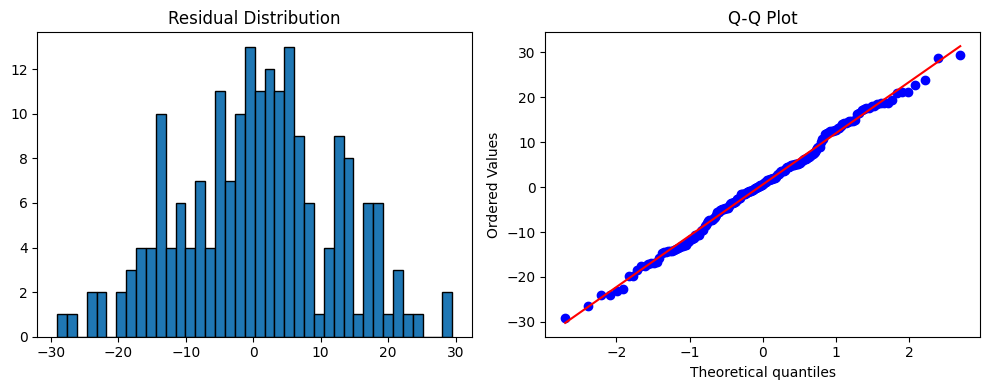

Shapiro-Wilk test statistic: 0.9953, p-value: 0.7860
Normal if p-value > 0.05


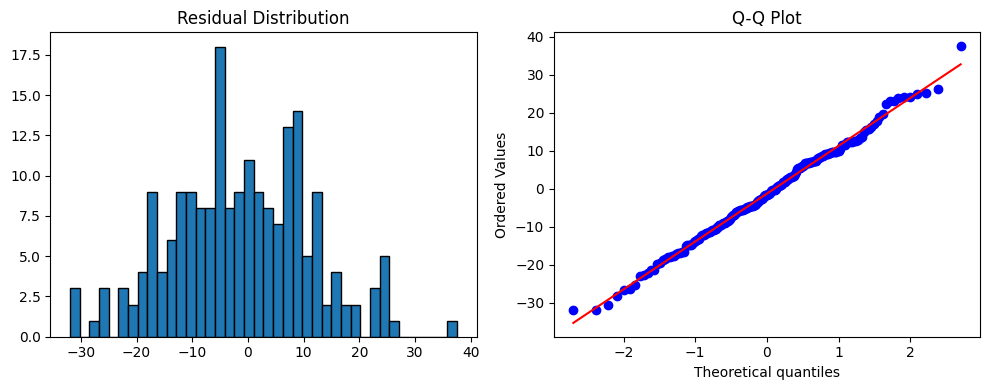

Pipeline

90% Confidence Intervals:
Predicted home points (DEN): 131.3 90% CI [112.7, 149.9]
Predicted away points (MEM): 114.6 90% CI [94.0, 135.1]
Predicted spread:  +16.7 90% CI [-11.0, 44.4]
Predicted total:   245.9 90% CI [218.2, 273.6]

95% Confidence Intervals:
Predicted home points (DEN): 131.3 95% CI [109.2, 153.5]
Predicted away points (MEM): 114.6 95% CI [90.1, 139.1]
Predicted spread:  +16.7 95% CI [-16.3, 49.8]
Predicted total:   245.9 95% CI [212.9, 278.9]

99% Confidence Intervals:
Predicted home points (DEN): 131.3 99% CI [102.2, 160.4]
Predicted away points (MEM): 114.6 99% CI [82.4, 146.8]
Predicted spread:  +16.7 99% CI [-26.7, 60.1]
Predicted total:   245.9 99% CI [202.5, 289.3]
Shapiro-Wilk test statistic: 0.9993, p-value: 0.5303
Normal if p-value > 0.05


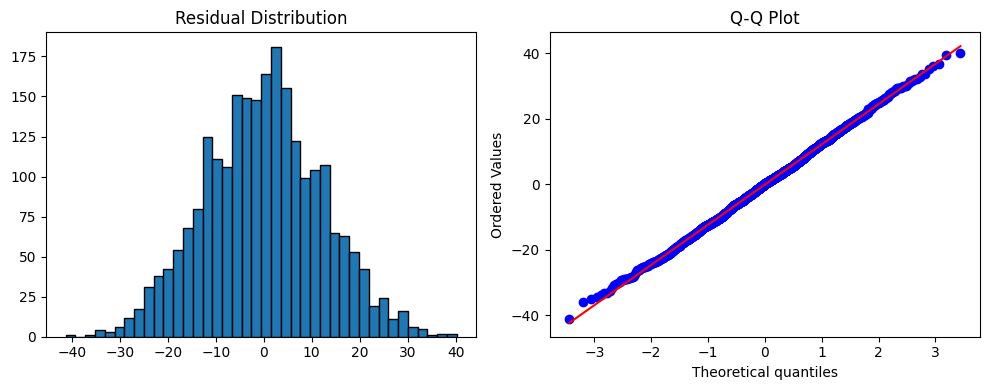

Shapiro-Wilk test statistic: 0.9991, p-value: 0.2811
Normal if p-value > 0.05


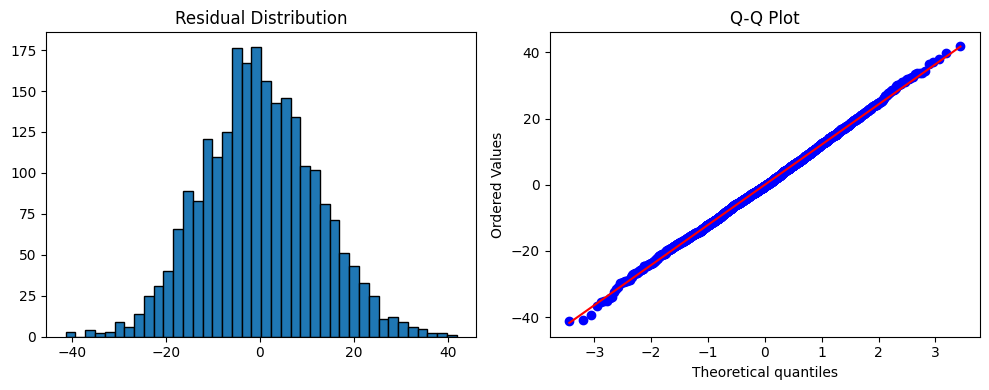

RandomForestRegressor

90% Confidence Intervals:
Predicted home points (DEN): 127.0 90% CI [106.8, 147.2]
Predicted away points (MEM): 113.3 90% CI [93.3, 133.3]
Predicted spread:  +13.7 90% CI [-14.7, 42.1]
Predicted total:   240.3 90% CI [211.9, 268.7]

95% Confidence Intervals:
Predicted home points (DEN): 127.0 95% CI [102.9, 151.0]
Predicted away points (MEM): 113.3 95% CI [89.5, 137.1]
Predicted spread:  +13.7 95% CI [-20.1, 47.5]
Predicted total:   240.3 95% CI [206.5, 274.1]

99% Confidence Intervals:
Predicted home points (DEN): 127.0 99% CI [95.4, 158.6]
Predicted away points (MEM): 113.3 99% CI [82.1, 144.5]
Predicted spread:  +13.7 99% CI [-30.8, 58.1]
Predicted total:   240.3 99% CI [195.8, 284.7]
Shapiro-Wilk test statistic: 0.9895, p-value: 0.1533
Normal if p-value > 0.05


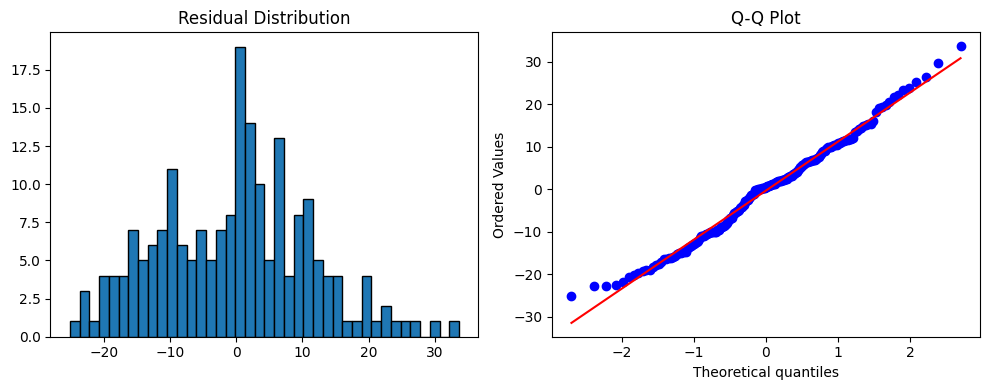

Shapiro-Wilk test statistic: 0.9953, p-value: 0.7878
Normal if p-value > 0.05


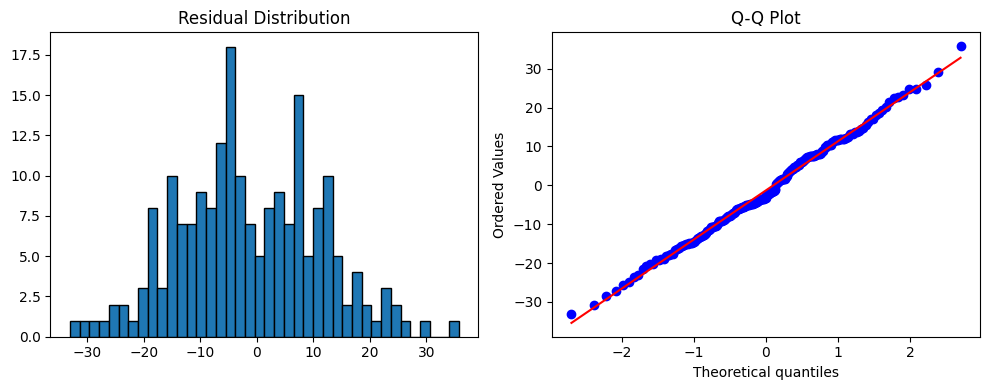

GradientBoostingRegressor

90% Confidence Intervals:
Predicted home points (DEN): 128.5 90% CI [109.6, 147.3]
Predicted away points (MEM): 108.9 90% CI [88.4, 129.5]
Predicted spread:  +19.5 90% CI [-8.4, 47.4]
Predicted total:   237.4 90% CI [209.5, 265.3]

95% Confidence Intervals:
Predicted home points (DEN): 128.5 95% CI [106.0, 150.9]
Predicted away points (MEM): 108.9 95% CI [84.4, 133.5]
Predicted spread:  +19.5 95% CI [-13.7, 52.7]
Predicted total:   237.4 95% CI [204.2, 270.6]

99% Confidence Intervals:
Predicted home points (DEN): 128.5 99% CI [99.0, 157.9]
Predicted away points (MEM): 108.9 99% CI [76.7, 141.2]
Predicted spread:  +19.5 99% CI [-24.2, 63.2]
Predicted total:   237.4 99% CI [193.7, 281.1]
Shapiro-Wilk test statistic: 0.9916, p-value: 0.2995
Normal if p-value > 0.05


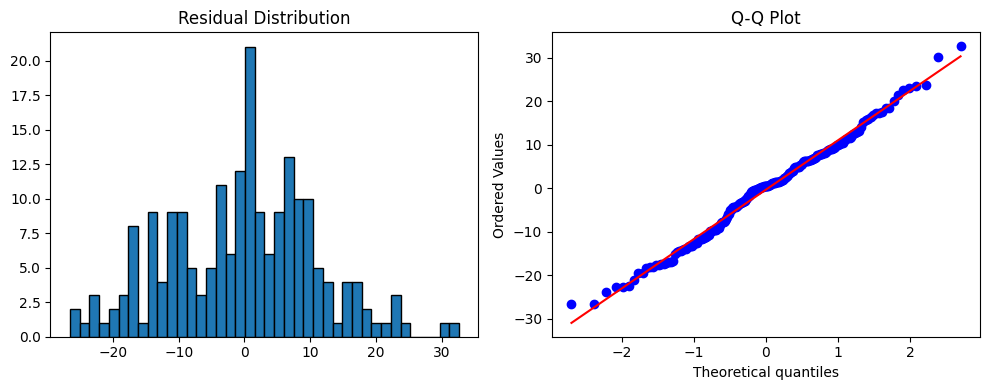

Shapiro-Wilk test statistic: 0.9953, p-value: 0.7873
Normal if p-value > 0.05


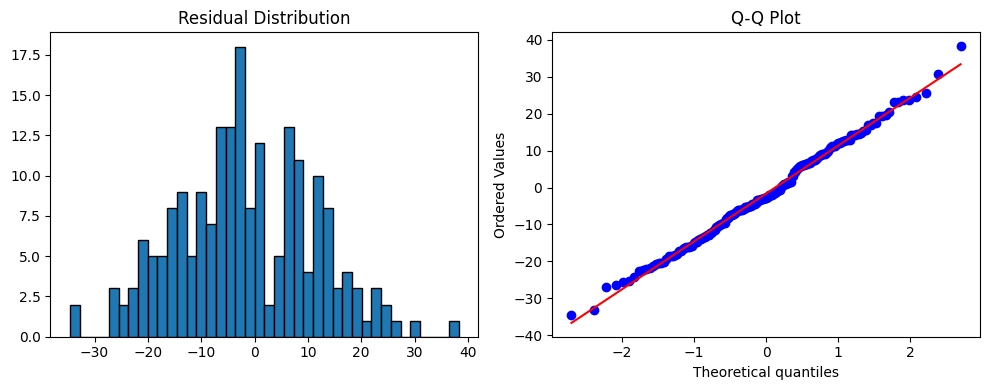

XGBRegressor

90% Confidence Intervals:
Predicted home points (DEN): 132.4 90% CI [113.9, 150.9]
Predicted away points (MEM): 117.3 90% CI [96.1, 138.4]
Predicted spread:  +15.2 90% CI [-12.9, 43.3]
Predicted total:   249.7 90% CI [221.6, 277.8]

95% Confidence Intervals:
Predicted home points (DEN): 132.4 95% CI [110.4, 154.5]
Predicted away points (MEM): 117.3 95% CI [92.0, 142.5]
Predicted spread:  +15.2 95% CI [-18.3, 48.7]
Predicted total:   249.7 95% CI [216.2, 283.2]

99% Confidence Intervals:
Predicted home points (DEN): 132.4 99% CI [103.4, 161.4]
Predicted away points (MEM): 117.3 99% CI [84.1, 150.4]
Predicted spread:  +15.2 99% CI [-28.9, 59.2]
Predicted total:   249.7 99% CI [205.7, 293.7]


In [119]:
ridge_home_pred, ridge_away_pred, ridge_home_resid_std, ridge_away_resid_std = predict_game_points("DEN", "MEM", datetime(2026, 4, 8), teams_rolling_stats, training_data, team_df, models['Ridge Regression'])
rf_home_pred, rf_away_pred, rf_home_resid_std, rf_away_resid_std = predict_game_points("DEN", "MEM", datetime(2026, 4, 8), teams_rolling_stats, training_data, team_df, models['Random Forest'])
gb_home_pred, gb_away_pred, gb_home_resid_std, gb_away_resid_std = predict_game_points("DEN", "MEM", datetime(2026, 4, 8), teams_rolling_stats, training_data, team_df, models['Gradient Boosting'])
xgboost_home_pred, xgboost_away_pred, xgboost_home_resid_std, xgboost_away_resid_std = predict_game_points("DEN", "MEM", datetime(2026, 4, 8), teams_rolling_stats, training_data, team_df, models['XGBoost'])

In [112]:
from scipy.stats import norm

def print_probabilities(home_pred: float, 
                        away_pred: float, 
                        home_resid_std: float, 
                        away_resid_std: float, 
                        line: float | None, 
                        total_line: float | None, 
                        spread_line: float | None):
    
    results = {}

    if line:
        # P(home scores over a line)
        p_home_over = 1 - norm.cdf(line, loc=home_pred, scale=home_resid_std)
        results['home_over'] = p_home_over
        print(f"P(home scores over {line}): {p_home_over:.2%}")

    if total_line:
        # P(total goes over)
        total_std = np.sqrt(away_resid_std**2 + home_resid_std**2)  # assumes independence
        p_total_over = 1 - norm.cdf(total_line, loc=away_pred + home_pred, scale=total_std)
        results['total_over'] = p_total_over
        print(f"P(total scores over {total_line}): {p_total_over:.2%}")
    
    if spread_line:
        # P(home covers spread)
        p_home_covers = 1 - norm.cdf(spread_line, loc=home_pred - away_pred, scale=total_std)
        results['home_covers'] = p_home_covers
        print(f"P(home covers spread of {spread_line}): {p_home_covers:.2%}")

    if not results:
        print("No probabilities calculated. Please provide at least one of line, total_line, or spread_line.")

    return results

In [117]:
line = 130
total_line = 240
spread_line = 10

print("Random Forest Predictions and Probabilities:")
print_probabilities(rf_home_pred, rf_away_pred, rf_home_resid_std, rf_away_resid_std, line, total_line, spread_line)
print("\n")

print("Gradient Boosting Predictions and Probabilities:")
print_probabilities(gb_home_pred, gb_away_pred, gb_home_resid_std, gb_away_resid_std, line, total_line, spread_line)
print("\n")

print("XGBoost Predictions and Probabilities:")
print_probabilities(xgboost_home_pred, xgboost_away_pred, xgboost_home_resid_std, xgboost_away_resid_std, line, total_line, spread_line)
print("\n")

print("Ridge Regression Predictions and Probabilities:")
print_probabilities(ridge_home_pred, ridge_away_pred, ridge_home_resid_std, ridge_away_resid_std, line, total_line, spread_line)

Random Forest Predictions and Probabilities:
P(home scores over 130): 40.31%
P(total scores over 240): 50.67%
P(home covers spread of 10): 58.47%


Gradient Boosting Predictions and Probabilities:
P(home scores over 130): 44.62%
P(total scores over 240): 43.91%
P(home covers spread of 10): 71.24%


XGBoost Predictions and Probabilities:
P(home scores over 130): 58.51%
P(total scores over 240): 71.43%
P(home covers spread of 10): 61.88%


Ridge Regression Predictions and Probabilities:
P(home scores over 130): 54.61%
P(total scores over 240): 63.66%
P(home covers spread of 10): 65.53%


{'home_over': np.float64(0.5461446610143519),
 'total_over': np.float64(0.6365968795980906),
 'home_covers': np.float64(0.6553100715957167)}

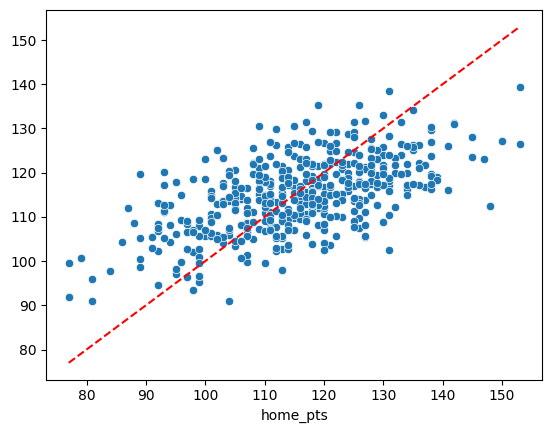

In [52]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(x=y_test, y=y_pred)

max_val = max(max(y_test), max(y_pred))
min_val = min(min(y_test), min(y_pred))
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='1:1 Line')

In [21]:
from nba_api.stats.endpoints import scoreboardv2

def get_schedule(game_date: str) -> pd.DataFrame:
    """
    Returns all scheduled games for a given date.
    Format: YYYY-MM-DD
    """

    scoreboard = scoreboardv2.ScoreboardV2(game_date=game_date)

    games = scoreboard.get_data_frames()[0]

    return games[['GAME_ID', 'GAME_DATE_EST', 'HOME_TEAM_ID', 'VISITOR_TEAM_ID']]

test_df = get_schedule("2026-03-01")
print(test_df.head())
print(test_df.columns)

      GAME_ID        GAME_DATE_EST  HOME_TEAM_ID  VISITOR_TEAM_ID
0  0022500868  2026-03-01T00:00:00    1610612752       1610612759
1  0022500869  2026-03-01T00:00:00    1610612751       1610612739
2  0022500870  2026-03-01T00:00:00    1610612741       1610612749
3  0022500871  2026-03-01T00:00:00    1610612743       1610612750
4  0022500872  2026-03-01T00:00:00    1610612754       1610612763
Index(['GAME_ID', 'GAME_DATE_EST', 'HOME_TEAM_ID', 'VISITOR_TEAM_ID'], dtype='str')
